In [1]:
import sys
import os
# sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd

In [2]:
model_names = ["llava-v1.6-vicuna-7b-hf", "Qwen2.5-VL-7B-Instruct", "InternVL2-8B"]

In [4]:
for i in range(len(model_names)):
    data_name = f"results/inference/okvqa/validation/{model_names[i]}_output.csv"
    data_df = pd.read_csv(data_name, index_col=0)
    print(data_df.head())

                                            question answer generated_outputs
0               What is in the motorcyclist's mouth?      D                 D
1  Which number birthday is probably being celebr...      D                 D
2             What best describes the pool of water?      C                 C
3  What is the white substance on top of the cupc...      D                 D
4  What type of device is sitting next to the lap...      B                 B
                                            question answer generated_outputs
0               What is in the motorcyclist's mouth?      D          stant\nD
1  Which number birthday is probably being celebr...      D          stant\nD
2             What best describes the pool of water?      C          stant\nC
3  What is the white substance on top of the cupc...      D          stant\nD
4  What type of device is sitting next to the lap...      B          stant\nB
                                            question answer gene

In [82]:
from data_generator.inference_loader import load_infer_mc_data
# model_outs, _, _ = load_infer_mc_data(model_names, "okvqa", "validation")

In [18]:
from data_generator.data_loader import DataCreator

ds_creator = DataCreator("mmmu")
i = 0
skip_list = []
for dataset_obj in ds_creator.get("validation"):
    for example in dataset_obj:
        images = [example[f"image_{i}"] for i in range(1, 8) if example[f"image_{i}"] is not None]
        if len(images) != 1 or example.get("question_type", "multiple-choice") == "open":
            skip_list.append(i)
            print(i)
        i+= 1
        
        

Loading MMMU dataset: 100%|██████████| 30/30 [00:31<00:00,  1.04s/it, status=Loading Sociology...]                          


55
73
83
120
123
130
135
146
159
163
189
203
208
213
219
221
222
227
228
229
232
234
235
238
239
252
278
280
292
295
297
345
373
379
384
391
393
394
395
400
401
405
410
413
414
415
416
418
419
457
459
466
469
472
473
474
479
483
493
495
501
524
527
544
572
586
589
590
592
594
610
639
644
657
662
674
678
708
720
735
740
742
748
752
753
767
768
771
775
800
810
826
829
830
839


In [19]:
i

900

In [3]:
from data_generator.inference_loader import load_infer_prob_data
from ens_pruning.ens_methods import voting

dataset_name = "mmmu" # okvqa
data = load_infer_prob_data(model_names, dataset_name, "validation")
label = data[:, -1]

model_probs = np.split(data[:, :-1], 3, axis=1)
model_preds = []
for i in range(len(model_names)):
    print(np.mean(model_probs[i].argmax(1) == label))
    model_preds.append(model_probs[i].argmax(1))

model_preds = np.array(model_preds)
voting_ens = voting(model_preds.T, "plurality")

classifications = (model_preds == label).sum(axis=0)

/home/hice1/stekin6/.conda/envs/llamas/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.3627329192546584
0.515527950310559
0.5130434782608696


In [4]:
classifications

array([1, 2, 0, 0, 0, 0, 2, 0, 3, 1, 0, 3, 1, 3, 0, 1, 2, 0, 2, 2, 2, 1,
       2, 1, 2, 1, 1, 0, 3, 1, 2, 3, 1, 1, 0, 1, 1, 1, 1, 0, 2, 0, 0, 3,
       2, 3, 1, 2, 3, 1, 2, 0, 1, 3, 2, 3, 1, 3, 3, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 2, 1, 1, 1, 3, 0, 2, 2, 2, 1, 0, 1, 1, 2, 0, 0, 1, 1, 3,
       2, 2, 3, 3, 3, 1, 2, 0, 3, 2, 0, 3, 1, 0, 0, 1, 3, 0, 1, 3, 3, 3,
       2, 3, 1, 2, 2, 3, 3, 3, 1, 1, 2, 1, 2, 2, 3, 2, 2, 0, 3, 1, 2, 1,
       3, 3, 1, 2, 1, 2, 3, 1, 3, 2, 0, 3, 2, 2, 3, 0, 1, 2, 1, 1, 3, 0,
       2, 2, 0, 2, 2, 3, 1, 1, 1, 2, 2, 2, 2, 0, 3, 1, 0, 2, 1, 2, 0, 2,
       0, 3, 0, 2, 0, 2, 0, 2, 1, 1, 2, 3, 2, 2, 0, 0, 1, 1, 0, 0, 2, 1,
       1, 2, 1, 0, 0, 0, 2, 2, 1, 2, 0, 2, 1, 0, 0, 1, 1, 2, 0, 1, 3, 1,
       1, 1, 2, 3, 2, 1, 3, 1, 3, 1, 2, 2, 1, 1, 3, 1, 0, 0, 1, 1, 3, 1,
       1, 1, 0, 2, 3, 0, 2, 1, 3, 2, 0, 1, 1, 0, 2, 3, 3, 3, 1, 1, 1, 1,
       1, 2, 1, 3, 1, 2, 2, 0, 3, 2, 3, 3, 2, 3, 3, 2, 1, 0, 0, 0, 3, 1,
       2, 1, 2, 3, 2, 1, 1, 2, 2, 3, 2, 0, 2, 2, 0,

In [5]:
from models.multi_encoder import MultiEncoderSharedAutoencoder
from train_multi_encoder import  EmbeddingLoader, collate_fn
from torch.utils.data import Dataset, DataLoader


dataset_name = "mmmu"
val_dataset = EmbeddingLoader(dataset_name, model_names, split_type="validation")
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)


loading embeddings
embeddings are loaded


In [6]:
model_save_path = os.path.join("results", "latent_map_models", f"latent_map_model.pth")
dims = [1024, 3584, 1024]
enc_dec = MultiEncoderSharedAutoencoder(dims, latent_dim=512)
state_dict = torch.load(model_save_path, weights_only=True)
enc_dec.load_state_dict(state_dict)

<All keys matched successfully>

In [8]:
def wcss(vectors):
    """
    vectors: list or tensor of shape (n, d)
    returns: WCSS and mean distance
    """
    X = torch.stack(vectors)  # shape (n, d)
    centroid = X.mean(dim=0, keepdim=True)
    diffs = X - centroid
    wcss_val = (diffs ** 2).sum(dim=(0, -1))         # total sum of squares
    # mean_dist = torch.sqrt((diffs ** 2).sum(dim=1)).mean().item()  # mean Euclidean distance
    # return wcss_val, mean_dist
    return wcss_val


In [7]:
from scipy.stats import wasserstein_distance

def calc_emd_dist(latents, idx_1, idx_2):
    distances = []
    for i in range(latents[0].shape[0]):
        distances.append(wasserstein_distance(latents[idx_1][i].cpu().numpy(), latents[idx_2][i].cpu().numpy()))
    return distances

In [45]:
import torch.nn.functional as F
from scipy.stats import wasserstein_distance


enc_dec.to("cuda")
total_diff = []
diff_1, diff_2, diff_3 = [], [], []
for batch in val_dataloader:
    batch = [k.to("cuda").float() for k in batch]
    with torch.no_grad():
        latents, recons = enc_dec(batch)
    total_diff.append(wcss(latents))
    # diff_1.append(F.cosine_similarity(latents[0], latents[1]))
    # diff_2.append(F.cosine_similarity(latents[0], latents[2]))
    # diff_3.append(F.cosine_similarity(latents[1], latents[2]))

    diff_1.append(torch.sqrt((latents[0] - latents[1]).pow(2).sum(axis=1)))
    diff_2.append(torch.sqrt((latents[0] - latents[2]).pow(2).sum(axis=1)))
    diff_3.append(torch.sqrt((latents[1] - latents[2]).pow(2).sum(axis=1)))
    
    # Wasserstein_distance:
    # diff_1.append(torch.tensor(calc_emd_dist(latents, 0, 1)))
    # diff_2.append(torch.tensor(calc_emd_dist(latents, 0, 2)))
    # diff_3.append(torch.tensor(calc_emd_dist(latents, 1, 2)))

In [26]:
indices_to_remove = torch.tensor(skip_list)
indices_to_remove.shape


torch.Size([95])

In [29]:
diff_1_tensor = torch.cat(diff_1).cpu()
mask = torch.ones(diff_1_tensor.shape, dtype=torch.bool)
mask[indices_to_remove] = False



torch.Size([805])

In [11]:
agree_1 = (model_preds[0] == model_preds[1]).astype(int)
agree_2 = (model_preds[0] == model_preds[2]).astype(int)
agree_3 = (model_preds[1] == model_preds[2]).astype(int)

In [21]:
torch.cat(diff_1).shape

torch.Size([900])

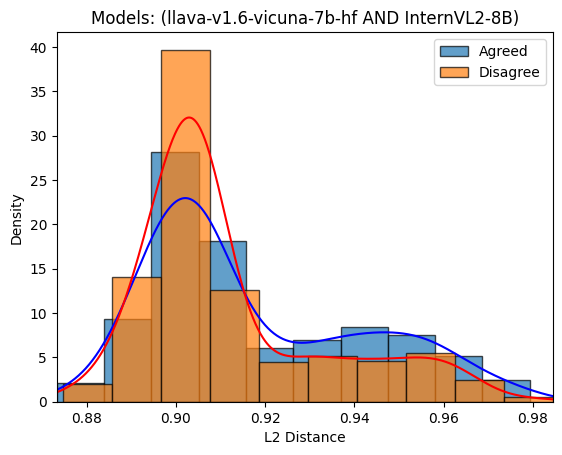

In [46]:
from scipy import stats

fig, ax = plt.subplots()

arr_1 = torch.cat(diff_1).cpu()[mask][agree_1.astype(bool)]
arr_2 = torch.cat(diff_1).cpu()[mask][~agree_1.astype(bool)]

max_val = torch.cat(diff_1).max().cpu()
min_val = torch.cat(diff_1).min().cpu()

xx = np.linspace(min_val, max_val, 1000)

ax.hist(arr_1, bins=10, alpha=0.7, edgecolor='black', color="tab:blue", label=f"Agreed", density=True, stacked=True)
kde = stats.gaussian_kde(arr_1)
ax.plot(xx, kde(xx), color="b")

ax.hist(arr_2, bins=10, alpha=0.7, edgecolor='black', color="tab:orange", label=f"Disagree", density=True, stacked=True)
kde = stats.gaussian_kde(arr_2)
ax.plot(xx, kde(xx), color="r")

ax.set_xlabel("L2 Distance")
ax.set_ylabel("Density")
ax.set_title(f"Models: ({model_names[0]} AND {model_names[2]})")

ax.set_xlim(min_val, max_val)
ax.legend()



Text(0.5, 1.0, 'Models: (llava-v1.6-vicuna-7b-hf AND Qwen2.5-VL-7B-Instruct)')

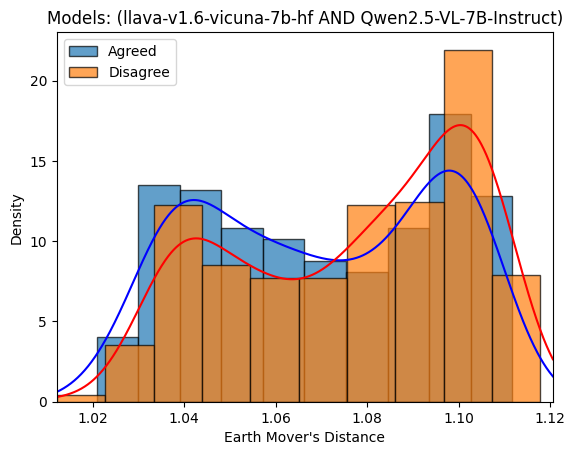

In [48]:
from scipy import stats

fig, ax = plt.subplots()

arr_1 = torch.cat(diff_2).cpu()[mask][agree_2[:1001].astype(bool)]
arr_2 = torch.cat(diff_2).cpu()[mask][~agree_2[:1001].astype(bool)]


max_val = torch.cat(diff_2).max().cpu()
min_val = torch.cat(diff_2).min().cpu()

xx = np.linspace(min_val, max_val, 1000)

ax.hist(arr_1, bins=10, alpha=0.7, edgecolor='black', color="tab:blue", label=f"Agreed", density=True, stacked=True)
kde = stats.gaussian_kde(arr_1)
ax.plot(xx, kde(xx), color="b")

ax.hist(arr_2, bins=10, alpha=0.7, edgecolor='black', color="tab:orange", label=f"Disagree", density=True, stacked=True)
kde = stats.gaussian_kde(arr_2)
ax.plot(xx, kde(xx), color="r")

ax.set_xlabel("Earth Mover's Distance")
ax.set_ylabel("Density")

ax.set_xlim(min_val, max_val)
ax.legend()
ax.set_title(f"Models: ({model_names[0]} AND {model_names[1]})")



Text(0.5, 1.0, 'Models: (Qwen2.5-VL-7B-Instruct AND InternVL2-8B)')

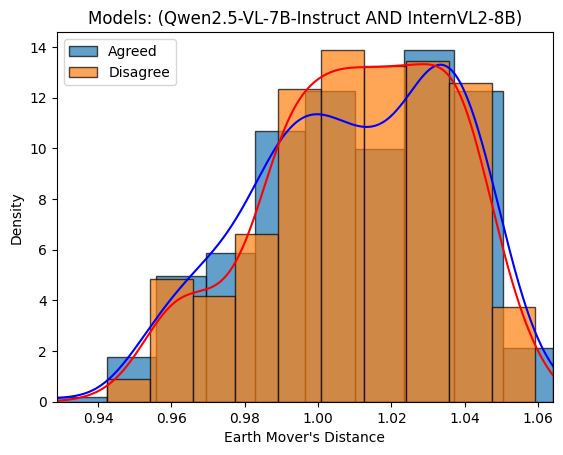

In [49]:
from scipy import stats

fig, ax = plt.subplots()

arr_1 = torch.cat(diff_3).cpu()[mask][agree_3[:1001].astype(bool)]
arr_2 = torch.cat(diff_3).cpu()[mask][~agree_3[:1001].astype(bool)]

max_val = torch.cat(diff_3).max().cpu()
min_val = torch.cat(diff_3).min().cpu()

xx = np.linspace(min_val, max_val, 1000)

ax.hist(arr_1, bins=10, alpha=0.7, edgecolor='black', color="tab:blue", label=f"Agreed", density=True, stacked=True)
kde = stats.gaussian_kde(arr_1)
ax.plot(xx, kde(xx), color="b")

ax.hist(arr_2, bins=10, alpha=0.7, edgecolor='black', color="tab:orange", label=f"Disagree", density=True, stacked=True)
kde = stats.gaussian_kde(arr_2)
ax.plot(xx, kde(xx), color="r")

ax.set_xlabel("Earth Mover's Distance")
ax.set_ylabel("Density")

ax.set_xlim(min_val, max_val)
ax.legend()
ax.set_title(f"Models: ({model_names[1]} AND {model_names[2]})")


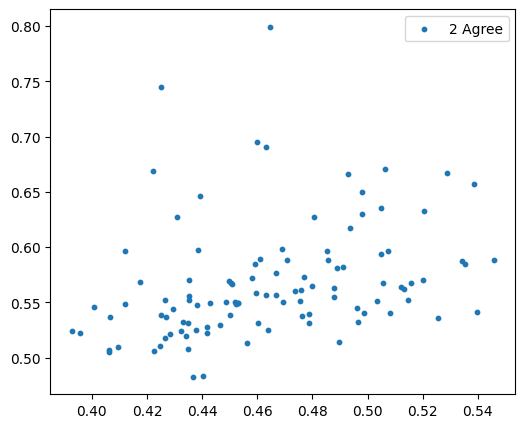

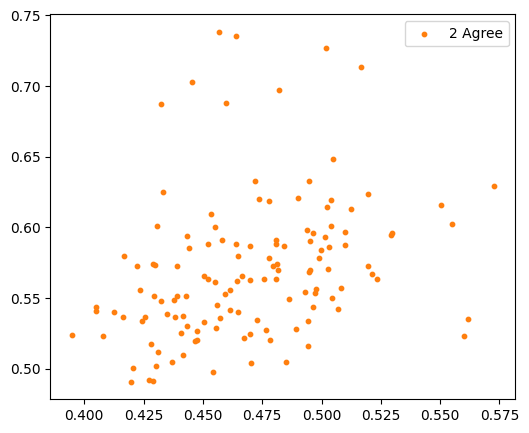

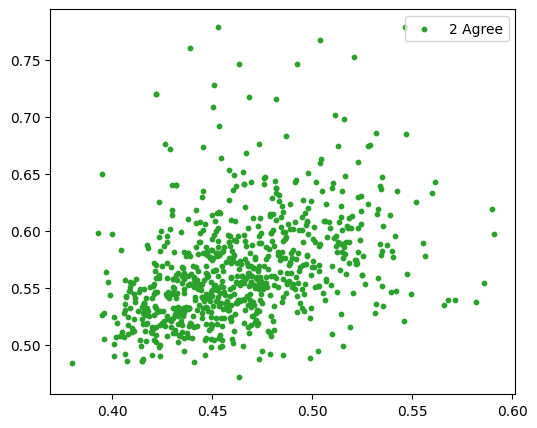

In [30]:

x1 = torch.cat(diff_1).cpu()
x2 = torch.cat(diff_2).cpu()
idx = (agree_1 + agree_2)[:1001]
for i in range(3):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(x1[idx==i], x2[idx==i], s=10, color=f"C{i}", label="2 Agree")
    # ax.scatter(x1[idx==1], x2[idx==1], s=10, label="1 Agree")
    # ax.scatter(x1[idx==0], x2[idx==0], s=10, label="0 Agree")

    ax.legend()

In [72]:
# np.apply_along_axis(lambda x: ["A", "B", "C", "D"].index(x), arr=data_df["answer"].values[:32], axis=0)
data_df["answer"].values[:32]

array(['D', 'D', 'C', 'D', 'B', 'A', 'C', 'B', 'A', 'D', 'A', 'C', 'A',
       'A', 'C', 'A', 'D', 'B', 'C', 'C', 'D', 'B', 'A', 'C', 'A', 'C',
       'D', 'C', 'D', 'A', 'C', 'A'], dtype=object)

In [ ]:
agree_1 = (model_preds[0] == model_preds[1]).astype(int)
agree_2 = (model_preds[0] == model_preds[2]).astype(int)

agree_1 + agree_2


array([2, 2, 1, ..., 1, 1, 2])

In [20]:
classifications[:32]

array([3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3,
       3, 3, 3, 3, 0, 2, 3, 0, 3, 3])

In [21]:
total_diff_arr = torch.cat(total_diff).cpu().numpy()

In [22]:
total_diff_arr[:10]

array([0.28685036, 0.2808267 , 0.2846068 , 0.41350788, 0.31888556,
       0.26527917, 0.28083465, 0.2793062 , 0.35924172, 0.29076037],
      dtype=float32)

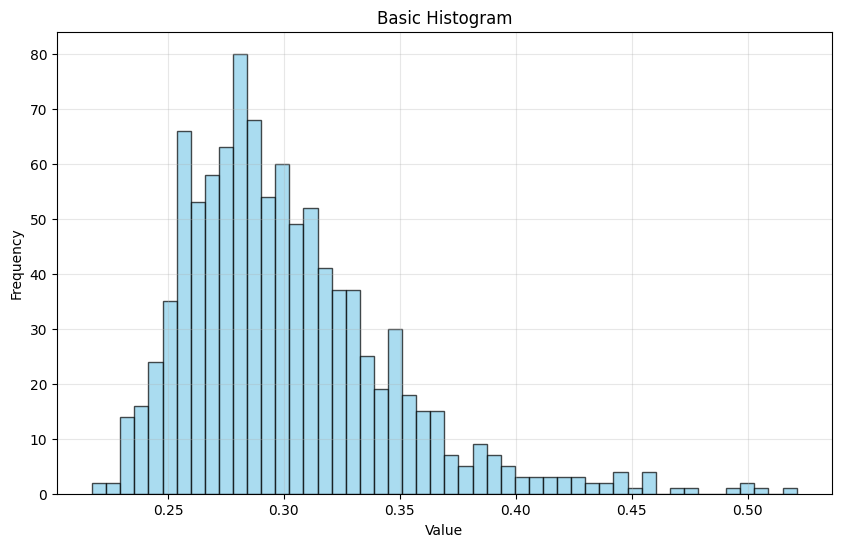

In [23]:

plt.figure(figsize=(10, 6))
plt.hist(total_diff_arr, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Basic Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()



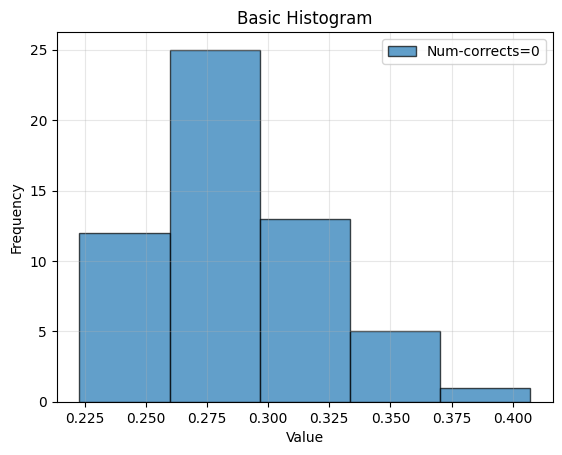

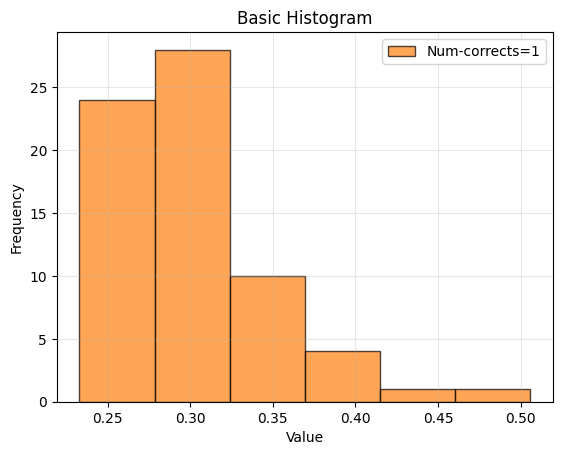

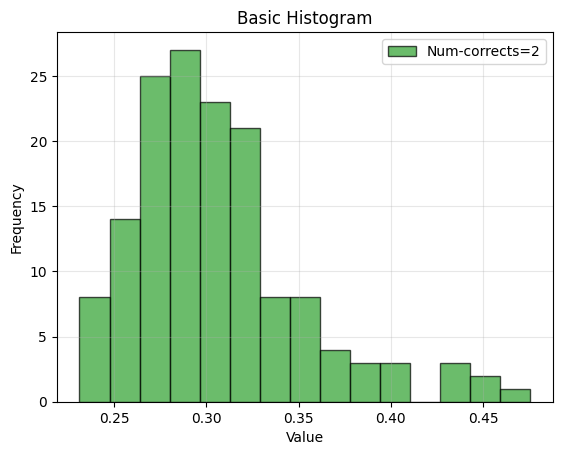

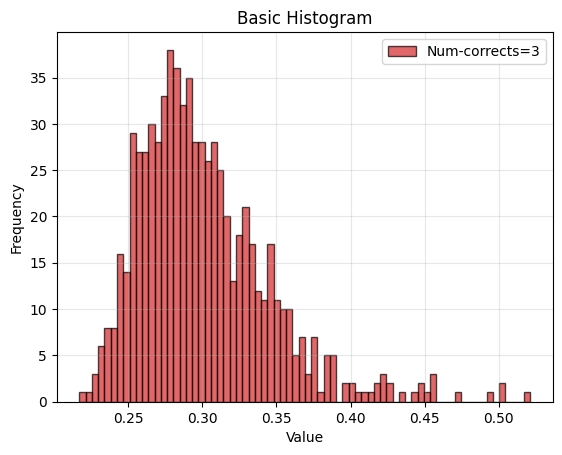

In [24]:
total_idx = classifications[:1001]

for i in range(4):
    idx = total_idx == i
    plt.figure()
    plt.hist(total_diff_arr[idx], bins=sum(idx)//10, alpha=0.7, color=f"C{i}", edgecolor='black', label=f"Num-corrects={i}")
    # plt.xlim(0, 0.002)
    plt.title('Basic Histogram')
    plt.legend()
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.show()


In [103]:
total_idx == 3

array([ True,  True, False, ...,  True,  True, False])

In [1]:
from datasets import load_dataset

mmmu_val = load_dataset("MMMU/MMMU", "val")
mmmu_pro_test = load_dataset("MMMU/MMMU_Pro", "test")

val_ids = set(mmmu_val['id'])
pro_test_ids = set(mmmu_pro_test['id'])

overlap = val_ids.intersection(pro_test_ids)

print("Number of overlapping samples:", len(overlap))
print("Example overlapping IDs:", list(overlap)[:10])

# Now filter test set
mmmu_pro_test_clean = mmmu_pro_test.filter(lambda x: x['id'] not in overlap)

print("Original test size:", len(mmmu_pro_test))
print("Cleaned test size:", len(mmmu_pro_test_clean))

/home/hice1/stekin6/.conda/envs/llamas/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ValueError: BuilderConfig 'val' not found. Available: ['Accounting', 'Agriculture', 'Architecture_and_Engineering', 'Art', 'Art_Theory', 'Basic_Medical_Science', 'Biology', 'Chemistry', 'Clinical_Medicine', 'Computer_Science', 'Design', 'Diagnostics_and_Laboratory_Medicine', 'Economics', 'Electronics', 'Energy_and_Power', 'Finance', 'Geography', 'History', 'Literature', 'Manage', 'Marketing', 'Materials', 'Math', 'Mechanical_Engineering', 'Music', 'Pharmacy', 'Physics', 'Psychology', 'Public_Health', 'Sociology']

In [3]:
mmmu_val = load_dataset("MMMU/MMMU", "Accounting")

Generating test split: 100%|██████████| 380/380 [00:00<00:00, 4311.91 examples/s]


In [8]:
mmmu_val["validation"]["id"]

['validation_Accounting_1',
 'validation_Accounting_2',
 'validation_Accounting_3',
 'validation_Accounting_4',
 'validation_Accounting_5',
 'validation_Accounting_6',
 'validation_Accounting_7',
 'validation_Accounting_8',
 'validation_Accounting_9',
 'validation_Accounting_10',
 'validation_Accounting_11',
 'validation_Accounting_12',
 'validation_Accounting_13',
 'validation_Accounting_14',
 'validation_Accounting_15',
 'validation_Accounting_16',
 'validation_Accounting_17',
 'validation_Accounting_18',
 'validation_Accounting_19',
 'validation_Accounting_20',
 'validation_Accounting_21',
 'validation_Accounting_22',
 'validation_Accounting_23',
 'validation_Accounting_24',
 'validation_Accounting_25',
 'validation_Accounting_26',
 'validation_Accounting_27',
 'validation_Accounting_28',
 'validation_Accounting_29',
 'validation_Accounting_30']

In [10]:
mmmu_pro_test = load_dataset("MMMU/MMMU_Pro", "standard (10 options)")

Generating test split: 100%|██████████| 1730/1730 [00:03<00:00, 575.47 examples/s]


In [18]:
count = 0
for d_id in mmmu_pro_test["test"]["id"]:
    if "test" in d_id:
        count+=1
print(count)

1153


In [16]:
count

577

In [19]:
1153 + 577

1730